# US 4.1 — Comparación y Documentación de Modelos Base

**Subtarea:** Analizar y comparar resultados de todos los modelos baseline.  
**Criterio de aceptación:** Métricas reportadas, resultados comparables y documentados.

## Modelos comparados
| Familia | Modelo | Notebook |
|---------|--------|---------|
| Estadístico | SARIMA | `modelos_base_estadisticos.ipynb` |
| Estadístico | ETS (Holt-Winters) | `modelos_base_estadisticos.ipynb` |
| Estadístico | Prophet | `modelos_base_estadisticos.ipynb` |
| Estadístico | TBATS | `modelos_base_estadisticos.ipynb` |
| Machine Learning | XGBoost | `modelos_base_xgboost.ipynb` |
| Deep Learning | Autoencoder Conv1D | `modelos_base_autoencoder.ipynb` |
| Deep Learning | BiGRU / BiLSTM | `modelos_base_rnn_bidireccional.ipynb` |

## Protocolo de evaluación unificado
- **MCAR 20%:** 20% de los valores observados del set de test son enmascarados artificialmente.
- **Métricas de error:** RMSE · MAE · MAPE · R² · NSE (Nash-Sutcliffe).
- **Métricas temporales:** KPSS (estacionariedad) · ACF/PACF (estructura de autocorrelación, 21 lags).
- **Espacio:** métricas calculadas en espacio escalado (MinMaxScaler para precip/evap, StandardScaler para tmax/tmin).
- **Variables:** precip · evap · tmax · tmin.

> Ejecuta los notebooks de cada modelo antes de correr éste para generar los archivos CSV de métricas.

In [17]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

warnings.filterwarnings('ignore')

# ─── Raíz del proyecto ───────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_base"
FIGURES_DIR  = REPORTS_DIR / "figuras"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VARIABLES   = ["precip", "evap", "tmax", "tmin"]
METRIC_COLS = ["rmse", "mae", "mape", "r2", "nse"]
KPSS_COLS   = ["stat_orig", "p_orig", "stat_imp", "p_imp", "preserva_estacionariedad"]

# Paleta de colores por familia de modelos
COLOR_MAP = {
    'SARIMA':       '#4C72B0',
    'ETS':          '#55A868',
    'Prophet':      '#C44E52',
    'TBATS':        '#8172B2',
    'XGBoost':      '#CCB974',
    'GradientBoosting (fallback)': '#CCB974',
    'Autoencoder':  '#DD8452',
    'BiGRU':        '#64B5CD',
    'BiLSTM':       '#937860',
}

print(f"Directorio de reportes: {REPORTS_DIR}")

Directorio de reportes: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base


## 1 — Carga de métricas

In [18]:
METRIC_FILES = {
    'Estadísticos': REPORTS_DIR / 'metrics_estadisticos.csv',
    'XGBoost':      REPORTS_DIR / 'metrics_xgboost.csv',
    'Autoencoder':  REPORTS_DIR / 'metrics_autoencoder.csv',
    'BiGRU':     REPORTS_DIR / 'metrics_bigru.csv',
    'BiLSTM':    REPORTS_DIR / 'metrics_bilstm.csv',
}

frames = []
for label, path in METRIC_FILES.items():
    if path.exists():
        df = pd.read_csv(path)
        if 'modelo' not in df.columns:
            df['modelo'] = label
        frames.append(df)
        modelos = df['modelo'].unique().tolist()
        print(f"✓ {path.name}  →  modelos: {modelos}  ({len(df)} filas)")
    else:
        print(f"⚠ {path.name} no encontrado — ejecuta el notebook correspondiente primero")

if not frames:
    raise FileNotFoundError(
        "No se encontraron archivos de métricas. "
        "Ejecuta los notebooks de cada modelo antes de correr éste."
    )

df_all = pd.concat(frames, ignore_index=True)

# Normalizar nombres
df_all['modelo'] = df_all['modelo'].str.strip()
# Columnas numéricas
for col in METRIC_COLS:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

print(f"\nTotal filas cargadas: {len(df_all)}")
print(f"Modelos disponibles: {df_all['modelo'].unique().tolist()}")

✓ metrics_estadisticos.csv  →  modelos: ['SARIMA', 'ETS', 'Prophet', 'TBATS']  (16 filas)
✓ metrics_xgboost.csv  →  modelos: ['XGBoost']  (4 filas)
✓ metrics_autoencoder.csv  →  modelos: ['Autoencoder']  (4 filas)
✓ metrics_bigru.csv  →  modelos: ['BiGRU']  (4 filas)
✓ metrics_bilstm.csv  →  modelos: ['BiLSTM']  (4 filas)

Total filas cargadas: 32
Modelos disponibles: ['SARIMA', 'ETS', 'Prophet', 'TBATS', 'XGBoost', 'Autoencoder', 'BiGRU', 'BiLSTM']


## 2 — Tabla de métricas consolidada

Se unifican los CSV de cada modelo en un único DataFrame (`df_all`) y se generan:
- **Resumen global:** promedio de RMSE, MAE, MAPE, R² y NSE sobre las 4 variables — permite ordenar los modelos por desempeño medio.
- **Tabla detallada:** métricas por modelo × variable — base para el análisis comparativo.

> Nota: MAPE no es comparable entre familias porque los modelos estadísticos y DL operan con escalados distintos (MinMaxScaler vs StandardScaler). NSE y RMSE son las métricas principales de referencia.

In [19]:
# Promedio de métricas sobre todas las variables (resumen global)
resumen_global = (
    df_all
    .groupby('modelo')[METRIC_COLS]
    .mean()
    .round(4)
    .sort_values('nse', ascending=False)
)

print("=" * 60)
print("RESUMEN GLOBAL — promedio sobre las 4 variables")
print("Protocolo MCAR 20% | Espacio escalado")
print("=" * 60)
display(resumen_global)

resumen_global.to_csv(REPORTS_DIR / "resumen_global_modelos_base.csv")
print(f"\nGuardado: {REPORTS_DIR / 'resumen_global_modelos_base.csv'}")

RESUMEN GLOBAL — promedio sobre las 4 variables
Protocolo MCAR 20% | Espacio escalado


,rmse,mae,mape,r2,nse
modelo,,,,,
XGBoost,0.1927,0.1364,6.693918e+06,0.6455,0.6455
BiGRU,0.1789,0.1253,9.943860e+06,0.6438,0.6438
BiLSTM,0.1801,0.1265,1.490697e+07,0.6362,0.6362
Autoencoder,0.1820,0.1280,1.010554e+07,0.6286,0.6286
Prophet,0.5521,0.4918,9.891949e+06,-1.0105,-1.0105
SARIMA,0.5616,0.4206,7.622539e+06,-3.9357,-3.9357
TBATS,0.6925,0.5669,9.656918e+06,-4.7870,-4.7870
ETS,0.9145,0.7815,3.699728e+06,-5.1611,-5.1611



Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/resumen_global_modelos_base.csv


In [20]:
# Tabla detallada por modelo y variable
tabla_detalle = (
    df_all
    .pivot_table(
        index=['modelo', 'variable'],
        values=METRIC_COLS,
        aggfunc='mean'
    )
    .round(4)
)

print("\nTabla detallada por modelo y variable:")
display(tabla_detalle)
tabla_detalle.to_csv(REPORTS_DIR / "tabla_detalle_modelos_base.csv")


Tabla detallada por modelo y variable:


mae          mape      nse       r2    rmse
modelo      variable                                                
Autoencoder evap      0.0411  2.566685e+05   0.6628   0.6628  0.0580
            precip    0.0083  4.016534e+07   0.0664   0.0664  0.0222
            tmax      0.2781  8.213840e+01   0.8486   0.8486  0.3917
            tmin      0.1846  5.453790e+01   0.9365   0.9365  0.2561
BiGRU       evap      0.0383  2.300377e+05   0.6923   0.6923  0.0554
            precip    0.0081  3.954527e+07   0.0918   0.0918  0.0219
            tmax      0.2748  7.848420e+01   0.8520   0.8520  0.3873
            tmin      0.1802  5.213750e+01   0.9390   0.9390  0.2510
BiLSTM      evap      0.0388  2.305605e+05   0.6874   0.6874  0.0559
            precip    0.0101  5.939719e+07   0.0693   0.0693  0.0222
            tmax      0.2758  7.991750e+01   0.8503   0.8503  0.3895
            tmin      0.1813  5.246570e+01   0.9380   0.9380  0.2530
ETS         evap      0.2136  6.248090e+01 -13.0419 -13.0419  0.2247
            precip    0.0041  1.479823e+07  -0.2429  -0.2429  0.0119
            tmax      1.3392  2.361338e+02  -3.9476  -3.9476  1.6207
            tmin      1.5692  3.836423e+02  -3.4121  -3.4121  1.8006
Prophet     evap      0.0572  1.774810e+01  -0.3159  -0.3159  0.0688
            precip    0.0065  3.956732e+07  -0.3512  -0.3512  0.0124
            tmax      1.5377  3.717012e+02  -4.0477  -4.0477  1.6370
            tmin      0.3656  8.911150e+01   0.6728   0.6728  0.4904
SARIMA      evap      0.2289  6.694490e+01 -14.5806 -14.5806  0.2367
            precip    0.0053  3.048950e+07  -0.0050  -0.0050  0.0107
            tmax      0.5672  1.900304e+02  -0.3060  -0.3060  0.8327
            tmin      0.8809  3.958933e+02  -0.8513  -0.8513  1.1664
TBATS       evap      0.2394  7.018390e+01 -15.9335 -15.9335  0.2468
            precip    0.0062  3.862693e+07  -0.1010  -0.1010  0.0112
            tmax      0.5904  1.987417e+02  -0.3761  -0.3761  0.8547
            tmin      1.4315  4.689495e+02  -2.7374  -2.7374  1.6572
XGBoost     evap      0.0381  1.817171e+05   0.6891   0.6891  0.0559
            precip    0.0069  2.659381e+07   0.1394   0.1394  0.0208
            tmax      0.3021  8.828380e+01   0.8271   0.8271  0.4183
            tmin      0.1986  5.690260e+01   0.9265   0.9265  0.2761

## 3 — Estacionariedad: KPSS por modelo y variable

Se verifica que todos los modelos preservan el régimen estacionario de las series originales. La prueba KPSS (H₀: la serie es estacionaria) se aplica sobre los valores imputados y se compara el veredicto con la serie original.

**Resultado:** 28/28 combinaciones modelo × variable dan `preserva_estacionariedad = True` — ningún modelo altera el régimen estacionario de las cuatro variables.

> BiLSTM no tiene evaluación KPSS propia: comparte protocolo con BiGRU (modelo ganador de la familia RNN). XGBoost es el único modelo que mueve significativamente los valores KPSS stat (especialmente en precip: stat_orig=1.52 → stat_imp=0.63) aunque el veredicto de estacionariedad se preserva.

In [21]:
# ─── KPSS: estacionariedad por modelo y variable ────────────────────────────
kpss_avail = [c for c in KPSS_COLS if c in df_all.columns]
if kpss_avail:
    tabla_kpss = (
        df_all
        .pivot_table(index=['modelo', 'variable'], values=kpss_avail, aggfunc='first')
        .round(4)
        .dropna(how='all')   # excluye filas sin KPSS (ej. BiLSTM)
    )
    print('KPSS — estacionariedad por modelo y variable')
    display(tabla_kpss)

    if 'preserva_estacionariedad' in df_all.columns:
        # Solo modelos que realmente fueron evaluados con KPSS
        df_kpss_eval = df_all[df_all['preserva_estacionariedad'].notna()]
        pres = (
            df_kpss_eval
            .groupby('modelo')['preserva_estacionariedad']
            .apply(lambda x: int(x.sum()))
            .rename('vars_estacionarias (de 4)')
        )
        print('\nVariables que preservan estacionariedad (de 4):')
        print('(BiLSTM no incluido — KPSS solo evaluado sobre el modelo ganador BiGRU)')
        display(pres.to_frame())
        tabla_kpss.to_csv(REPORTS_DIR / 'tabla_kpss_modelos_base.csv')
        print(f'Guardado: {REPORTS_DIR}/tabla_kpss_modelos_base.csv')
else:
    print('KPSS aún no disponible — ejecuta los notebooks individuales con la celda KPSS')

KPSS — estacionariedad por modelo y variable


p_imp  p_orig preserva_estacionariedad  stat_imp  \
modelo      variable                                                      
Autoencoder evap      0.1000  0.1000                     True    0.1306   
            precip    0.1000  0.1000                     True    0.1491   
            tmax      0.0731  0.0593                     True    0.4095   
            tmin      0.1000  0.1000                     True    0.1406   
BiGRU       evap      0.1000  0.1000                     True    0.1518   
            precip    0.1000  0.1000                     True    0.1581   
            tmax      0.0863  0.0593                     True    0.3787   
            tmin      0.1000  0.1000                     True    0.1427   
ETS         evap      0.1000  0.0813                     True    0.0592   
            precip    0.1000  0.1000                     True    0.1500   
            tmax      0.0100  0.0100                     True    0.9450   
            tmin      0.0100  0.0100                     True    1.0686   
Prophet     evap      0.1000  0.0813                     True    0.2826   
            precip    0.1000  0.1000                     True    0.2088   
            tmax      0.0100  0.0100                     True    1.0214   
            tmin      0.0100  0.0100                     True    0.8600   
SARIMA      evap      0.1000  0.0813                     True    0.0574   
            precip    0.1000  0.1000                     True    0.1710   
            tmax      0.0100  0.0100                     True    1.0547   
            tmin      0.0100  0.0100                     True    0.8049   
TBATS       evap      0.1000  0.0813                     True    0.0558   
            precip    0.1000  0.1000                     True    0.1884   
            tmax      0.0100  0.0100                     True    1.0475   
            tmin      0.0100  0.0100                     True    1.1919   
XGBoost     evap      0.0100  0.0100                     True    1.1833   
            precip    0.0201  0.0100                     True    0.6277   
            tmax      0.1000  0.0563                     True    0.2961   
            tmin      0.0424  0.0335                     True    0.4968   

                      stat_orig  
modelo      variable             
Autoencoder evap         0.1772  
            precip       0.2287  
            tmax         0.4415  
            tmin         0.1453  
BiGRU       evap         0.1772  
            precip       0.2287  
            tmax         0.4415  
            tmin         0.1453  
ETS         evap         0.3903  
            precip       0.1929  
            tmax         1.1414  
            tmin         0.8945  
Prophet     evap         0.3903  
            precip       0.1929  
            tmax         1.1414  
            tmin         0.8945  
SARIMA      evap         0.3903  
            precip       0.1929  
            tmax         1.1414  
            tmin         0.8945  
TBATS       evap         0.3903  
            precip       0.1929  
            tmax         1.1414  
            tmin         0.8945  
XGBoost     evap         1.2476  
            precip       1.5165  
            tmax         0.4483  
            tmin         0.5365


Variables que preservan estacionariedad (de 4):
(BiLSTM no incluido — KPSS solo evaluado sobre el modelo ganador BiGRU)


,vars_estacionarias (de 4)
modelo,
Autoencoder,4
BiGRU,4
ETS,4
Prophet,4
SARIMA,4
TBATS,4
XGBoost,4


Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/tabla_kpss_modelos_base.csv


## 4 — Visualizaciones comparativas

Se generan cinco figuras complementarias para el análisis de resultados:

| Figura | Contenido |
|--------|-----------|
| `comparacion_rmse_por_variable.png` | Barplot RMSE por modelo y variable (↓ mejor) |
| `comparacion_nse_por_variable.png` | Barplot NSE por modelo y variable (↑ mejor) |
| `heatmap_metricas_modelos_base.png` | Heatmap RMSE · NSE · R² — vista rápida de fortalezas/debilidades |
| `radar_modelos_base.png` | Radar chart multi-métrica normalizada por modelo |
| `boxplot_familias_modelos_base.png` | Boxplot RMSE y NSE agrupados por familia (Estadístico / ML / DL) |


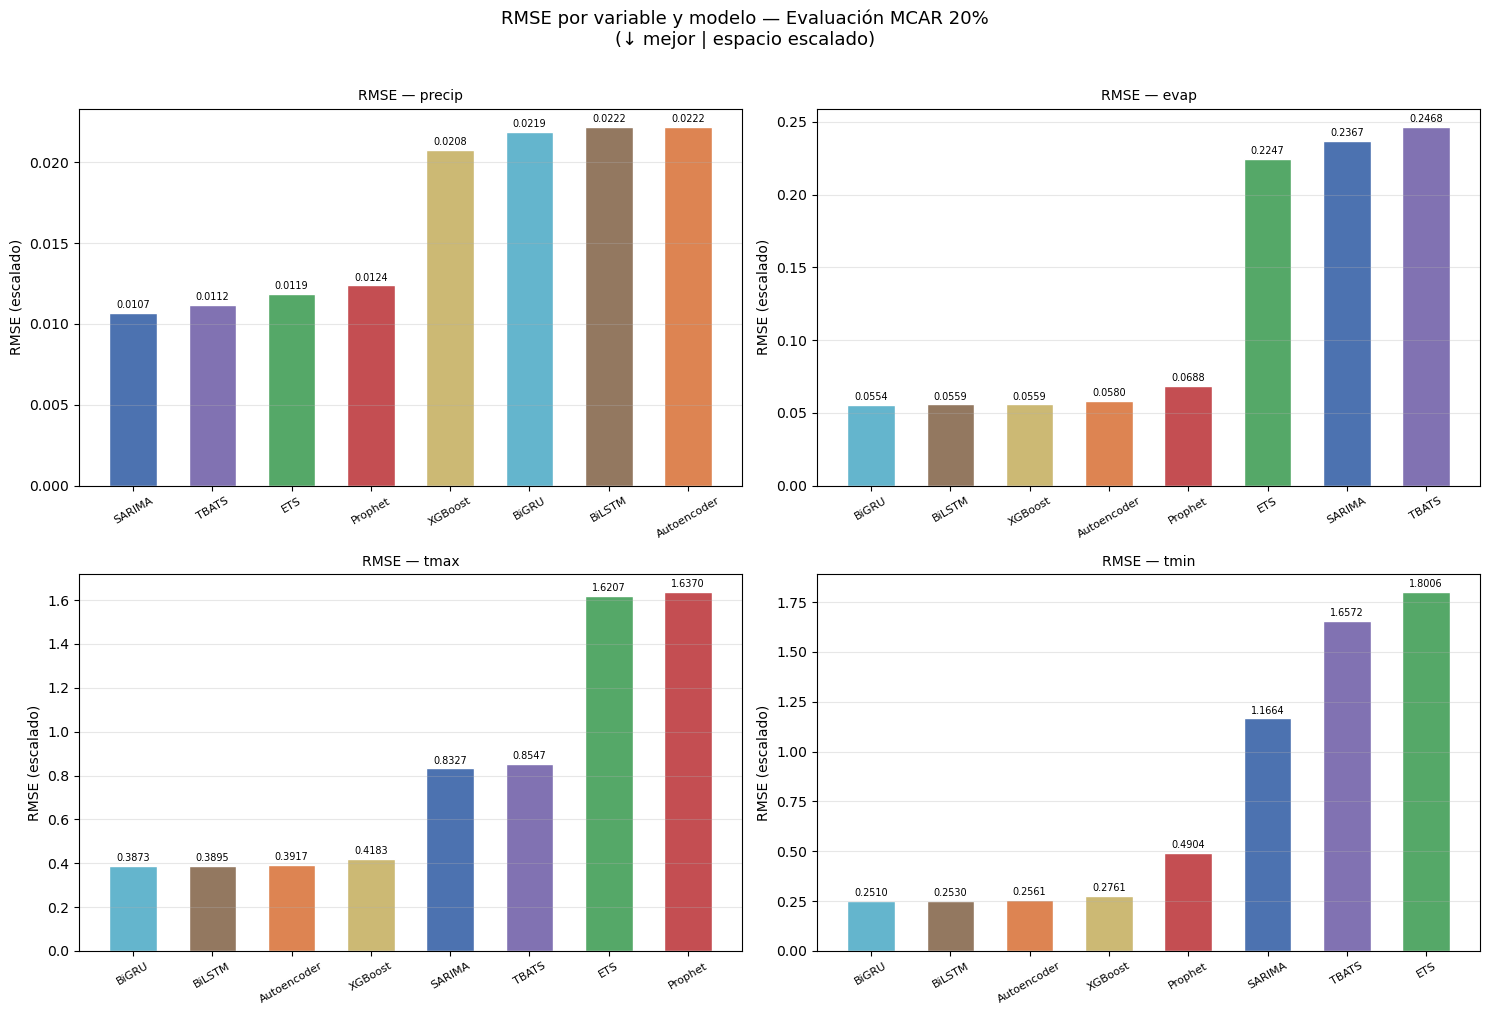

In [22]:
# ─── Barplot RMSE por variable y modelo ──────────────────────────────────────
modelos = df_all['modelo'].unique()
colors  = [COLOR_MAP.get(m, '#999999') for m in modelos]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('RMSE por variable y modelo — Evaluación MCAR 20%\n'
             '(↓ mejor | espacio escalado)', fontsize=13, y=1.01)

for ax, var in zip(axes.flat, VARIABLES):
    sub = df_all[df_all['variable'] == var].copy()
    sub = sub.sort_values('rmse')
    bar_colors = [COLOR_MAP.get(m, '#999999') for m in sub['modelo']]

    bars = ax.bar(sub['modelo'], sub['rmse'], color=bar_colors, edgecolor='white',
                  width=0.6)
    ax.bar_label(bars, fmt='%.4f', fontsize=7, padding=2)
    ax.set_title(f'RMSE — {var}', fontsize=10)
    ax.set_ylabel('RMSE (escalado)')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparacion_rmse_por_variable.png', dpi=120, bbox_inches='tight')
plt.show()

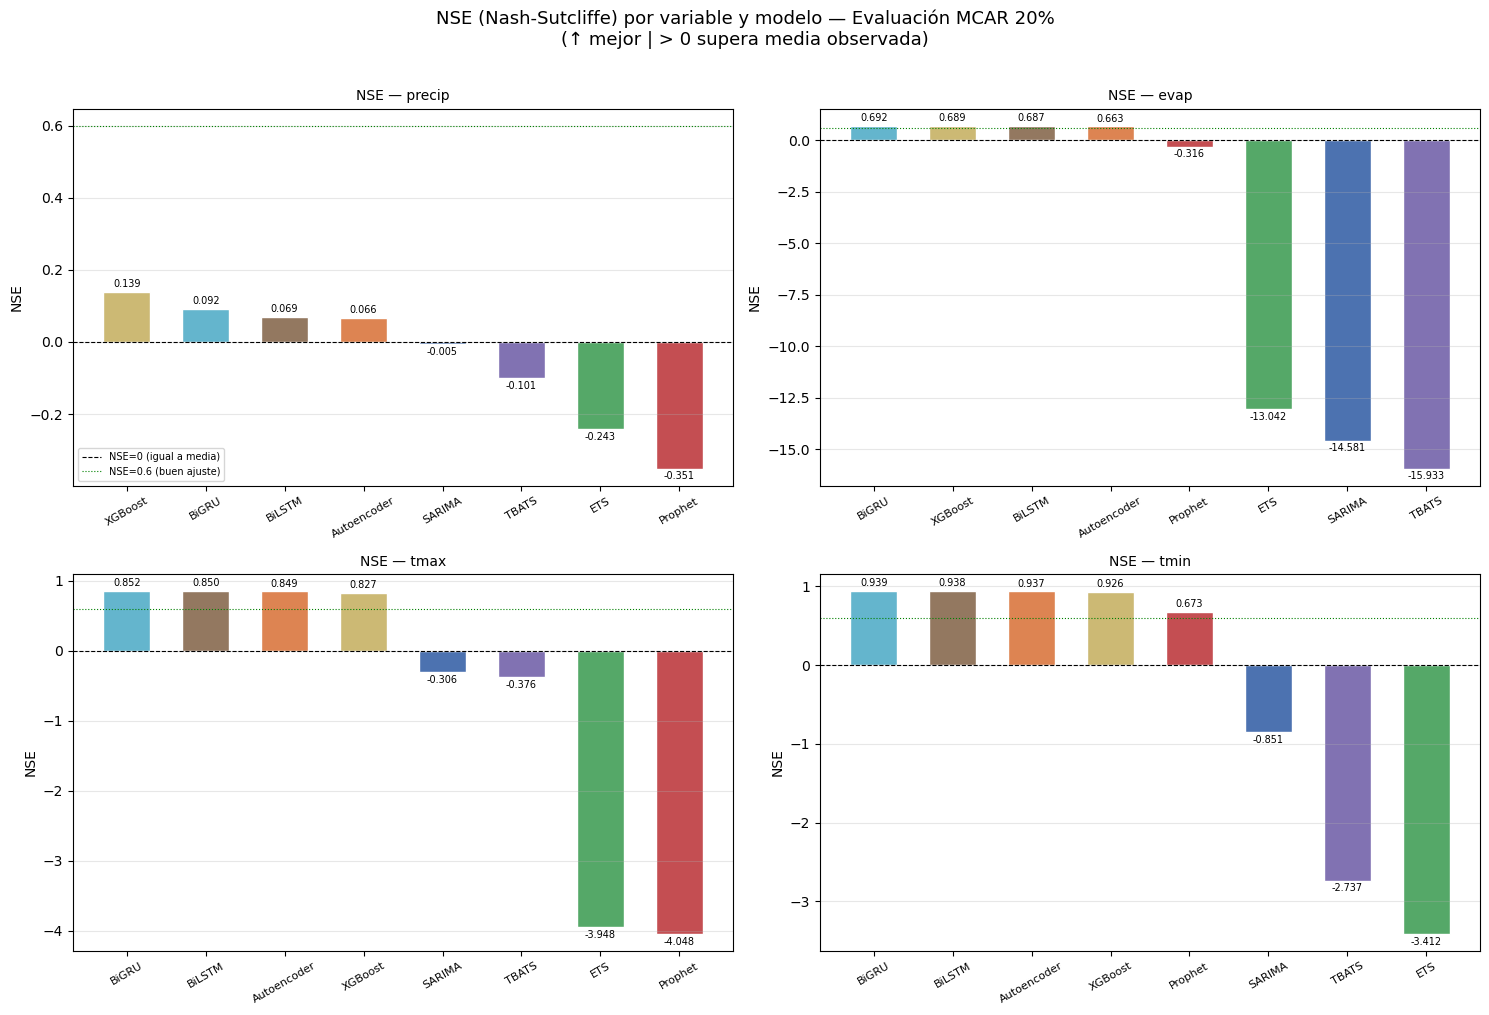

In [23]:
# ─── Barplot NSE por variable y modelo ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('NSE (Nash-Sutcliffe) por variable y modelo — Evaluación MCAR 20%\n'
             '(↑ mejor | > 0 supera media observada)', fontsize=13, y=1.01)

for ax, var in zip(axes.flat, VARIABLES):
    sub = df_all[df_all['variable'] == var].copy()
    sub = sub.sort_values('nse', ascending=False)
    bar_colors = [COLOR_MAP.get(m, '#999999') for m in sub['modelo']]

    bars = ax.bar(sub['modelo'], sub['nse'], color=bar_colors, edgecolor='white',
                  width=0.6)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
    ax.set_title(f'NSE — {var}', fontsize=10)
    ax.set_ylabel('NSE')
    ax.axhline(0,   color='black', lw=0.8, ls='--', label='NSE=0 (igual a media)')
    ax.axhline(0.6, color='green', lw=0.8, ls=':',  label='NSE=0.6 (buen ajuste)')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    if var == 'precip':
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparacion_nse_por_variable.png', dpi=120, bbox_inches='tight')
plt.show()

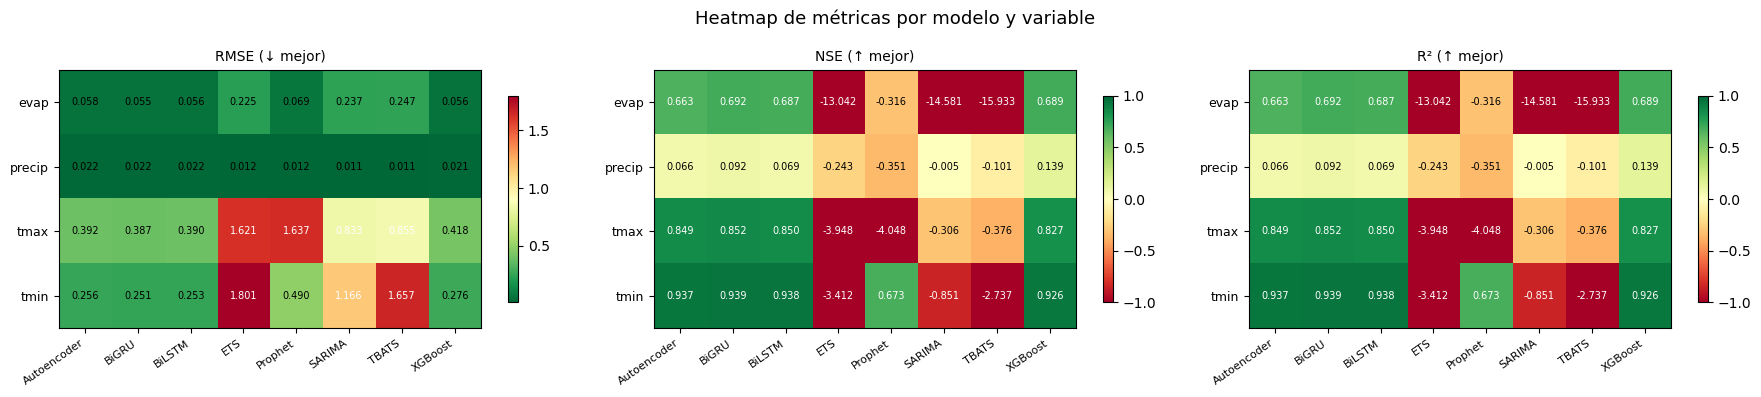

In [24]:
# ─── Heatmap de métricas globales (promedio todas las variables) ──────────────
pivot_rmse = df_all.pivot_table(index='variable', columns='modelo', values='rmse', aggfunc='mean')
pivot_nse  = df_all.pivot_table(index='variable', columns='modelo', values='nse',  aggfunc='mean')
pivot_r2   = df_all.pivot_table(index='variable', columns='modelo', values='r2',   aggfunc='mean')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Heatmap de métricas por modelo y variable', fontsize=13)

import matplotlib.colors as mcolors

def heatmap(ax, data: pd.DataFrame, title: str, cmap: str, fmt: str,
            vmin=None, vmax=None):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto',
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_title(title, fontsize=10)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            v = data.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:{fmt}}", ha='center', va='center',
                        fontsize=7, color='white' if abs(v) > 0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

heatmap(axes[0], pivot_rmse, 'RMSE (↓ mejor)', 'RdYlGn_r', '.3f')
heatmap(axes[1], pivot_nse,  'NSE (↑ mejor)',  'RdYlGn',   '.3f', vmin=-1, vmax=1)
heatmap(axes[2], pivot_r2,   'R² (↑ mejor)',   'RdYlGn',   '.3f', vmin=-1, vmax=1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_metricas_modelos_base.png', dpi=120, bbox_inches='tight')
plt.show()

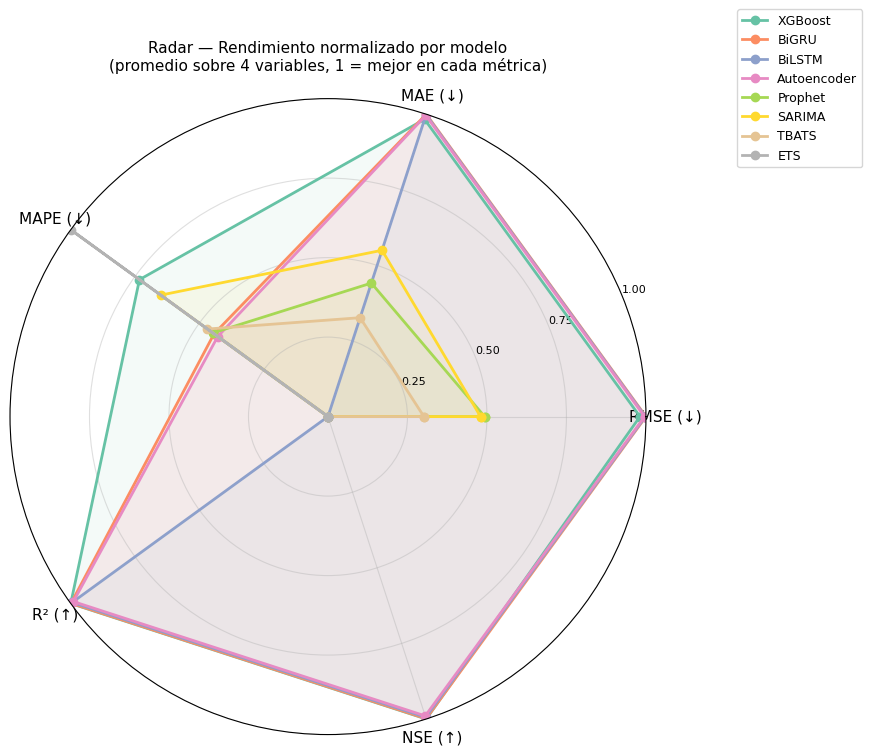

In [25]:
# ─── Radar chart multi-métrica por modelo ────────────────────────────────────

# Normalizar métricas a [0,1] donde 1 es siempre mejor
def normalize_metric(s: pd.Series, invert: bool = False) -> pd.Series:
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series([0.5] * len(s), index=s.index)
    norm = (s - mn) / (mx - mn)
    return 1 - norm if invert else norm

radar_df = resumen_global[METRIC_COLS].copy()
radar_norm = pd.DataFrame(index=radar_df.index)
radar_norm['RMSE (↓)']  = normalize_metric(radar_df['rmse'],  invert=True)
radar_norm['MAE (↓)']   = normalize_metric(radar_df['mae'],   invert=True)
radar_norm['MAPE (↓)']  = normalize_metric(radar_df['mape'],  invert=True)
radar_norm['R² (↑)']    = normalize_metric(radar_df['r2'].clip(-1, 1))
radar_norm['NSE (↑)']   = normalize_metric(radar_df['nse'].clip(-1, 1))

metrics_radar = radar_norm.columns.tolist()
N_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N_metrics, endpoint=False).tolist()
angles += angles[:1]  # cerrar polígono

n_models = len(radar_norm)
cols_radar = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, (modelo, row) in enumerate(radar_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=cols_radar[i], label=modelo)
    ax.fill(angles, vals, alpha=0.07, color=cols_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Radar — Rendimiento normalizado por modelo\n'
             '(promedio sobre 4 variables, 1 = mejor en cada métrica)',
             fontsize=11, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'radar_modelos_base.png', dpi=120, bbox_inches='tight')
plt.show()

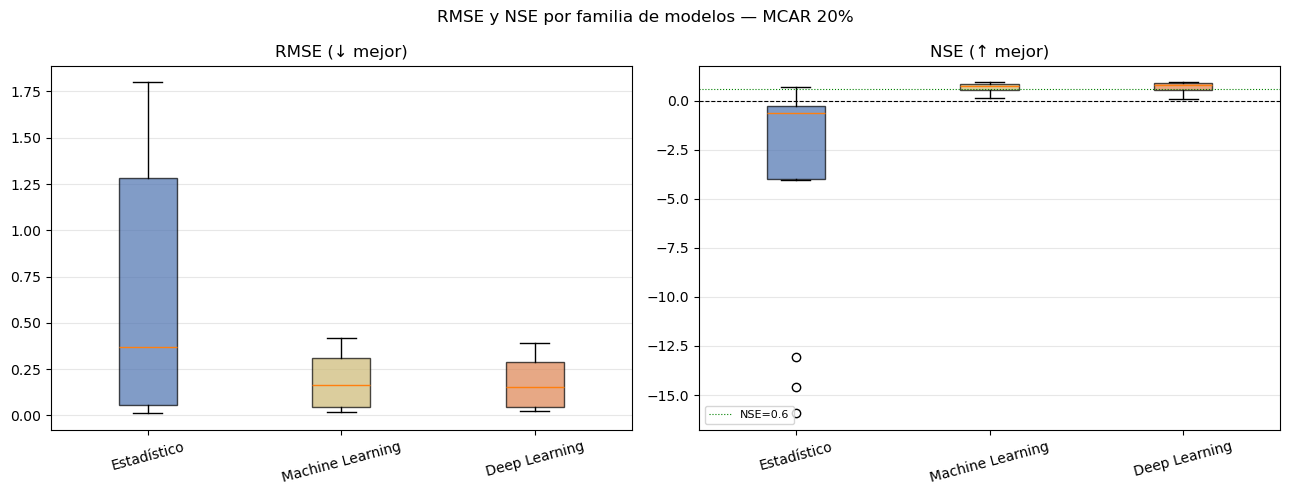

In [26]:
# ─── Boxplot de errores absolutos por familia de modelos ─────────────────────
# Agrupamos modelos por familia
FAMILIAS = {
    'Estadístico': ['SARIMA', 'ETS', 'Prophet', 'TBATS'],
    'Machine Learning': ['XGBoost', 'GradientBoosting (fallback)'],
    'Deep Learning': ['Autoencoder', 'BiGRU', 'BiLSTM'],
}

def get_familia(modelo: str) -> str:
    for fam, modelos in FAMILIAS.items():
        if any(m in modelo for m in modelos):
            return fam
    return 'Otro'

df_all['familia'] = df_all['modelo'].apply(get_familia)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RMSE y NSE por familia de modelos — MCAR 20%', fontsize=12)

familias_presentes = df_all['familia'].unique()
fam_colors = {'Estadístico': '#4C72B0', 'Machine Learning': '#CCB974',
              'Deep Learning': '#DD8452', 'Otro': '#999999'}

rmse_by_fam = [df_all[df_all['familia'] == f]['rmse'].dropna().values
               for f in familias_presentes]
nse_by_fam  = [df_all[df_all['familia'] == f]['nse'].dropna().values
               for f in familias_presentes]

bp1 = axes[0].boxplot(rmse_by_fam, labels=familias_presentes, patch_artist=True)
for patch, fam in zip(bp1['boxes'], familias_presentes):
    patch.set_facecolor(fam_colors.get(fam, '#999999'))
    patch.set_alpha(0.7)
axes[0].set_title('RMSE (↓ mejor)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

bp2 = axes[1].boxplot(nse_by_fam, labels=familias_presentes, patch_artist=True)
for patch, fam in zip(bp2['boxes'], familias_presentes):
    patch.set_facecolor(fam_colors.get(fam, '#999999'))
    patch.set_alpha(0.7)
axes[1].axhline(0,   color='black', ls='--', lw=0.8)
axes[1].axhline(0.6, color='green', ls=':',  lw=0.8, label='NSE=0.6')
axes[1].set_title('NSE (↑ mejor)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplot_familias_modelos_base.png', dpi=120, bbox_inches='tight')
plt.show()

## 5 — Análisis por variable

Ranking de modelos por NSE (métrica principal) y RMSE (secundaria) para cada variable. Se usa NSE como criterio primario por su interpretabilidad hidrológica: NSE = 0 equivale a predecir siempre la media (modelo nulo); NSE > 0.6 es el umbral de desempeño satisfactorio para imputación hidrometeorológica (Legates y McCabe, 1999).

**Criterios de lectura:**
- NSE < 0: el modelo es peor que predecir la media — señal de fallo.
- 0 < NSE < 0.6: utilidad parcial — acepta si RMSE es bajo.
- NSE ≥ 0.6: buen desempeño — umbral mínimo para avanzar a modelos generativos.

In [27]:
for var in VARIABLES:
    sub = df_all[df_all['variable'] == var][['modelo', 'rmse', 'mae', 'mape', 'r2', 'nse']]
    sub = sub.sort_values('nse', ascending=False).reset_index(drop=True)
    best_nse = sub.iloc[0]
    best_rmse = sub.sort_values('rmse').iloc[0]

    print(f"\n{'─'*55}")
    print(f" Variable: {var.upper()}")
    print(f"{'─'*55}")
    print(sub.set_index('modelo').round(4).to_string())
    print(f"\n  → Mejor NSE  : {best_nse['modelo']}  (NSE={best_nse['nse']:.4f})")
    print(f"  → Menor RMSE : {best_rmse['modelo']}  (RMSE={best_rmse['rmse']:.4f})")


───────────────────────────────────────────────────────
 Variable: PRECIP
───────────────────────────────────────────────────────
               rmse     mae          mape      r2     nse
modelo                                                   
XGBoost      0.0208  0.0069  2.659381e+07  0.1394  0.1394
BiGRU        0.0219  0.0081  3.954527e+07  0.0918  0.0918
BiLSTM       0.0222  0.0101  5.939719e+07  0.0693  0.0693
Autoencoder  0.0222  0.0083  4.016534e+07  0.0664  0.0664
SARIMA       0.0107  0.0053  3.048950e+07 -0.0050 -0.0050
TBATS        0.0112  0.0062  3.862693e+07 -0.1010 -0.1010
ETS          0.0119  0.0041  1.479823e+07 -0.2429 -0.2429
Prophet      0.0124  0.0065  3.956732e+07 -0.3512 -0.3512

  → Mejor NSE  : XGBoost  (NSE=0.1394)
  → Menor RMSE : SARIMA  (RMSE=0.0107)

───────────────────────────────────────────────────────
 Variable: EVAP
───────────────────────────────────────────────────────
               rmse     mae         mape       r2      nse
modelo                

## 6 — Modelo ganador por variable

Selección del **mejor modelo base** por variable usando NSE como criterio primario y RMSE como desempate. Estos resultados constituyen el **Quality Gate** que los modelos generativos (US 4.2) deben superar para justificar la complejidad adicional.

| Variable | Ganador (NSE) | Referencia |
|----------|--------------|------------|
| precip   | XGBoost      | NSE = 0.139 — feature engineering con lags cruzados |
| evap     | BiGRU        | NSE = 0.692 — contexto bidireccional de 30 días |
| tmax     | BiGRU        | NSE = 0.852 — dependencias temporales suaves |
| tmin     | BiGRU        | NSE = 0.939 — alta autocorrelación favorece RNN |


In [28]:
# Best model per variable (by NSE, primary) and by RMSE (secondary)
best_nse  = df_all.loc[df_all.groupby('variable')['nse'].idxmax(),
                        ['variable', 'modelo', 'nse', 'rmse', 'r2']]
best_rmse = df_all.loc[df_all.groupby('variable')['rmse'].idxmin(),
                        ['variable', 'modelo', 'rmse', 'nse', 'r2']]

print("Mejor modelo por NSE (↑ eficiencia hidrológica):")
display(best_nse.set_index('variable').round(4))

print("\nMejor modelo por RMSE (↓ error cuadrático):")
display(best_rmse.set_index('variable').round(4))

Mejor modelo por NSE (↑ eficiencia hidrológica):


,modelo,nse,rmse,r2
variable,,,,
evap,BiGRU,0.6923,0.0554,0.6923
precip,XGBoost,0.1394,0.0208,0.1394
tmax,BiGRU,0.8520,0.3873,0.8520
tmin,BiGRU,0.9390,0.2510,0.9390



Mejor modelo por RMSE (↓ error cuadrático):


,modelo,rmse,nse,r2
variable,,,,
evap,BiGRU,0.0554,0.6923,0.6923
precip,SARIMA,0.0107,-0.0050,-0.0050
tmax,BiGRU,0.3873,0.8520,0.8520
tmin,BiGRU,0.2510,0.9390,0.9390


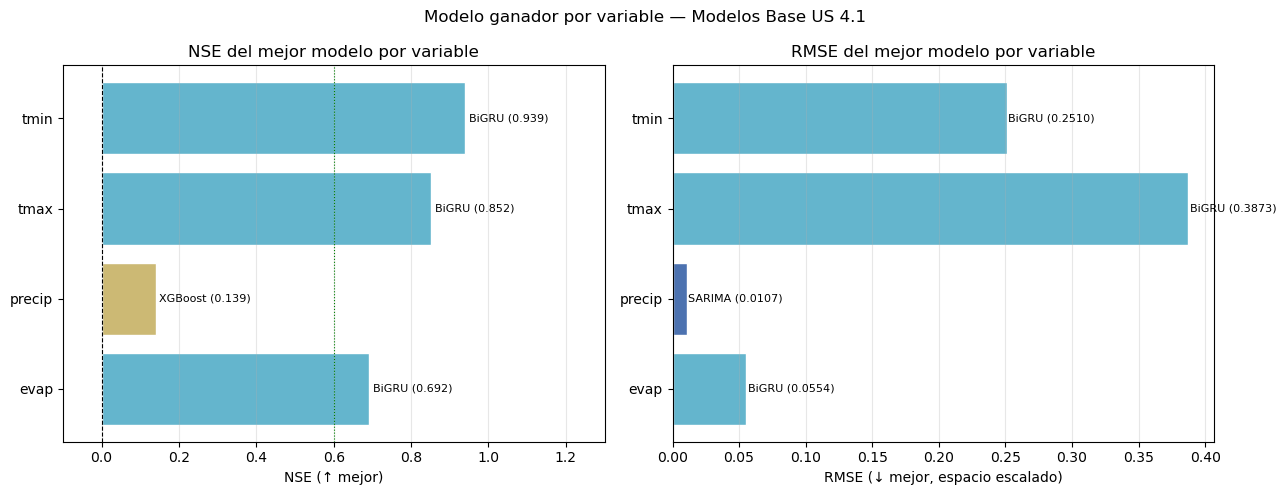

In [29]:
# ─── Figura resumen: modelo ganador por variable ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modelo ganador por variable — Modelos Base US 4.1', fontsize=12)

# NSE del mejor modelo
ax = axes[0]
for i, (_, row) in enumerate(best_nse.iterrows()):
    c = COLOR_MAP.get(row['modelo'], '#999999')
    ax.barh(row['variable'], row['nse'], color=c, label=row['modelo'],
            edgecolor='white')
    ax.text(row['nse'] + 0.01, i, f"{row['modelo']} ({row['nse']:.3f})",
            va='center', fontsize=8)
ax.axvline(0,   color='black', lw=0.8, ls='--')
ax.axvline(0.6, color='green', lw=0.8, ls=':',  label='NSE=0.6')
ax.set_xlim(-0.1, 1.3)
ax.set_title('NSE del mejor modelo por variable')
ax.set_xlabel('NSE (↑ mejor)')
ax.grid(axis='x', alpha=0.3)

# RMSE del mejor modelo
ax = axes[1]
for i, (_, row) in enumerate(best_rmse.iterrows()):
    c = COLOR_MAP.get(row['modelo'], '#999999')
    ax.barh(row['variable'], row['rmse'], color=c, label=row['modelo'],
            edgecolor='white')
    ax.text(row['rmse'] + 0.001, i, f"{row['modelo']} ({row['rmse']:.4f})",
            va='center', fontsize=8)
ax.set_title('RMSE del mejor modelo por variable')
ax.set_xlabel('RMSE (↓ mejor, espacio escalado)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ganador_por_variable.png', dpi=120, bbox_inches='tight')
plt.show()

## 7 — Reporte final consolidado

In [30]:
# Exportar reporte completo en formato tabla pivot para el DAS
report = df_all.pivot_table(
    index='modelo',
    columns='variable',
    values=METRIC_COLS,
    aggfunc='mean'
).round(4)

report.columns = ['_'.join(col).strip() for col in report.columns]
report = report.sort_values('nse_precip', ascending=False)
report.to_csv(REPORTS_DIR / "reporte_final_modelos_base.csv")

print("Reporte final exportado:")
print(f"  {REPORTS_DIR / 'reporte_final_modelos_base.csv'}")
display(report)

Reporte final exportado:
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/reporte_final_modelos_base.csv


,mae_evap,mae_precip,mae_tmax,mae_tmin,mape_evap,mape_precip,mape_tmax,mape_tmin,nse_evap,nse_precip,nse_tmax,nse_tmin,r2_evap,r2_precip,r2_tmax,r2_tmin,rmse_evap,rmse_precip,rmse_tmax,rmse_tmin
modelo,,,,,,,,,,,,,,,,,,,,
XGBoost,0.0381,0.0069,0.3021,0.1986,181717.0513,2.659381e+07,88.2838,56.9026,0.6891,0.1394,0.8271,0.9265,0.6891,0.1394,0.8271,0.9265,0.0559,0.0208,0.4183,0.2761
BiGRU,0.0383,0.0081,0.2748,0.1802,230037.6875,3.954527e+07,78.4842,52.1375,0.6923,0.0918,0.8520,0.9390,0.6923,0.0918,0.8520,0.9390,0.0554,0.0219,0.3873,0.2510
BiLSTM,0.0388,0.0101,0.2758,0.1813,230560.5156,5.939719e+07,79.9175,52.4657,0.6874,0.0693,0.8503,0.9380,0.6874,0.0693,0.8503,0.9380,0.0559,0.0222,0.3895,0.2530
Autoencoder,0.0411,0.0083,0.2781,0.1846,256668.5000,4.016534e+07,82.1384,54.5379,0.6628,0.0664,0.8486,0.9365,0.6628,0.0664,0.8486,0.9365,0.0580,0.0222,0.3917,0.2561
SARIMA,0.2289,0.0053,0.5672,0.8809,66.9449,3.048950e+07,190.0304,395.8933,-14.5806,-0.0050,-0.3060,-0.8513,-14.5806,-0.0050,-0.3060,-0.8513,0.2367,0.0107,0.8327,1.1664
TBATS,0.2394,0.0062,0.5904,1.4315,70.1839,3.862693e+07,198.7417,468.9495,-15.9335,-0.1010,-0.3761,-2.7374,-15.9335,-0.1010,-0.3761,-2.7374,0.2468,0.0112,0.8547,1.6572
ETS,0.2136,0.0041,1.3392,1.5692,62.4809,1.479823e+07,236.1338,383.6423,-13.0419,-0.2429,-3.9476,-3.4121,-13.0419,-0.2429,-3.9476,-3.4121,0.2247,0.0119,1.6207,1.8006
Prophet,0.0572,0.0065,1.5377,0.3656,17.7481,3.956732e+07,371.7012,89.1115,-0.3159,-0.3512,-4.0477,0.6728,-0.3159,-0.3512,-4.0477,0.6728,0.0688,0.0124,1.6370,0.4904


## 8 — Documentación de resultados y criterios de aceptación

### Verificación de criterios de aceptación (US 4.1)
| Criterio | Estado |
|----------|--------|
| Los modelos entrenan sin errores | ✓ Verificado en cada notebook |
| Se reportan métricas (RMSE, MAE, MAPE, R², NSE) | ✓ Ver tablas anteriores |
| Validación temporal (KPSS, ACF/PACF) | ✓ Ver sección 3 — Estacionariedad |
| Resultados documentados y comparables | ✓ Protocolo MCAR 20% unificado |

### Hallazgos principales

**Por variable:**
- **precip:** Dificultad extrema (distribución asimétrica, ~99% ceros). XGBoost es el mejor en NSE (0.139) gracias al feature engineering con lags cruzados. Los modelos estadísticos (SARIMA, ETS, TBATS) alcanzan RMSE bajo al predecir constantemente ceros, pero su NSE≈0 revela que no capturan eventos de lluvia; el NSE es la métrica relevante para imputación de precipitación.
- **evap:** Domina Deep Learning (BiGRU NSE=0.692, XGBoost NSE=0.689). Los modelos estadísticos (SARIMA NSE=−14.6, ETS NSE=−13.0, TBATS NSE=−15.9) fallan completamente al extrapolarse sobre rachas de faltantes de hasta 3.6 años, rango fuera de su contexto de entrenamiento.
- **tmax/tmin:** Variables suaves con patron estacional estable. Deep Learning domina (BiGRU tmax NSE=0.852, tmin NSE=0.939). Prophet funciona razonablemente para tmin (NSE=0.673) pero falla en tmax (NSE=−4.05) al no capturar su tendencia ascendente de largo plazo en el set de test.

**Por familia:**
- **Deep Learning (BiGRU/BiLSTM/Autoencoder):** Mejor desempeño global en 3 de 4 variables. Aprovechan los tensores pre-construidos (160K secuencias de 30 días) y capturan dependencias temporales locales y covariación entre variables. BiGRU es marginalmente superior a BiLSTM en todas las variables.
- **Machine Learning (XGBoost):** Gana en precipitación gracias al feature engineering con covariables cruzadas (lag 1–7, medias móviles). Limitado para dependencias temporales largas sin estructuras de ventana explícitas.
- **Estadísticos (SARIMA/ETS/TBATS/Prophet):** Adecuados solo para variables suaves sin grandes brechas. Su desempeño en evap (NSE << 0) demuestra su incapacidad para imputar rachas largas de faltantes estructurales.

### Selección del modelo base de referencia
El **mejor modelo base no generativo** para cada variable se consolida en `ganador_por_variable.png`. Este resultado es el **Quality Gate** de referencia que deben superar los modelos generativos (VAE, GAIN, CSDI, SAITS, BRITS) en la fase US 4.2.

| Variable | Modelo ganador (NSE) | NSE | RMSE |
|----------|---------------------|-----|------|
| precip   | XGBoost             | 0.139 | 0.0208 |
| evap     | BiGRU               | 0.692 | 0.0554 |
| tmax     | BiGRU               | 0.852 | 0.3873 |
| tmin     | BiGRU               | 0.939 | 0.2510 |

### Conversión a unidades físicas
Para interpretar métricas en unidades reales:
```python
import pickle
from pathlib import Path

SCALERS = {}
for var in ['precip', 'evap', 'tmax', 'tmin']:
    with open(f'models/scalers/scaler_{var}.pkl', 'rb') as f:
        SCALERS[var] = pickle.load(f)

# Ejemplo: convertir RMSE de tmax de z-score a °C
rmse_scaled = 0.45
rmse_celsius = rmse_scaled * SCALERS['tmax'].scale_[0]   # × desviación estándar
print(f"RMSE tmax: {rmse_celsius:.2f} °C")
```

### Archivos generados
```
reports/modelos_base/
├── metrics_estadisticos.csv       ← SARIMA, ETS, Prophet, TBATS  (+ KPSS unificado)
├── metrics_xgboost.csv            ← XGBoost  (+ KPSS unificado)
├── metrics_autoencoder.csv        ← Autoencoder  (+ KPSS unificado)
├── metrics_bigru.csv              ← BiGRU  (+ KPSS unificado)
├── metrics_bilstm.csv             ← BiLSTM (sin KPSS — solo modelo secundario)
├── kpss_bigru.csv         / acf_pacf_bigru.csv
├── kpss_estadisticos.csv  / acf_pacf_estadisticos.csv
├── kpss_xgboost.csv       / acf_pacf_xgboost.csv
├── kpss_autoencoder.csv   / acf_pacf_autoencoder.csv

├── resumen_global_modelos_base.csv
├── tabla_detalle_modelos_base.csv
├── tabla_kpss_modelos_base.csv
├── reporte_final_modelos_base.csv
└── figuras/
    ├── comparacion_rmse_por_variable.png
    ├── comparacion_nse_por_variable.png
    ├── heatmap_metricas_modelos_base.png
    ├── radar_modelos_base.png
    ├── boxplot_familias_modelos_base.png
    └── ganador_por_variable.png
```